In [1]:
import os
import numpy as np
from typing import List, Tuple
from PIL import Image
import matplotlib.pyplot as plt
from pixel import PangoCairoBigramsRenderer

%matplotlib inline

In [2]:
# default values
DEFAULT_FONT_SIZE = 13
DEFAULT_PPB = 32
MAX_SEQ_LENGTH = 25
MAX_PIXELS_LEN = MAX_SEQ_LENGTH * DEFAULT_PPB

# NOTE that we use a different font size for Figure 1 than in the experiments to increase visibility

In [3]:
  # Define helper function to show a single image
def show_images(images: List[np.ndarray], name:str="test.pdf") -> None:
    save_base: str = os.getcwd()
    n: int = len(images)
    f = plt.figure(figsize=(20, 5))
    for i in range(n):
        # token figure
        ax = f.add_subplot(1, n, i + 1)
        plt.imshow(images[i],cmap='gray', vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(os.path.join(save_base, name), bbox_inches="tight", dpi=500)
    plt.show(block=True)

In [4]:
fallback_fonts_dir="../fonts/fonts"
bigrams_renderer = PangoCairoBigramsRenderer(
    fallback_fonts_dir="../fonts/fonts",
    rgb=False,
    max_seq_length = MAX_SEQ_LENGTH, 
    font_file='%s/NotoSans-Regular.ttf' % fallback_fonts_dir,   
    font_size=DEFAULT_FONT_SIZE,
    pixels_per_patch=DEFAULT_PPB
)

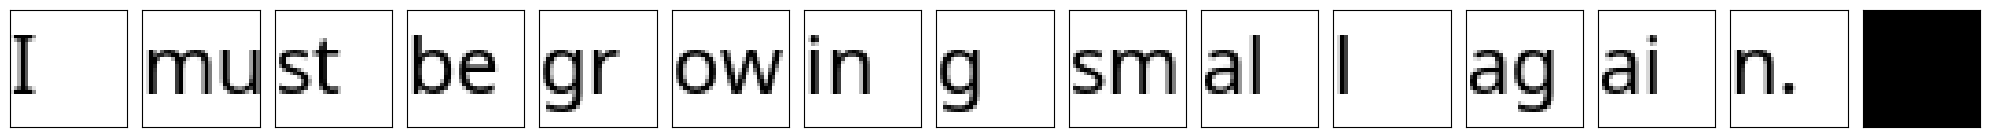

In [5]:
sentence = 'I must be growing small again.'
encoding = bigrams_renderer(sentence)

image_pieces = []
window = DEFAULT_PPB

for idx in range(0, encoding.num_text_patches):
    start = idx*window
    token = encoding.pixel_values[:,start:start+window]
    image_pieces.append(token)
eos = encoding.num_text_patches*window
image_pieces.append(encoding.pixel_values[:,eos:eos+window])
image_pieces.pop(2) # empty patch because of forced spaced between characters. Removed for clarity.
show_images(image_pieces, name="bigrams.pdf")